# Diabetes Prediction — EDA & Model Training

## Dataset Description

**Source:** `diabetes_012_health_indicators_BRFSS2015.csv` (CDC BRFSS 2015 survey)

The dataset contains **253,680 survey responses** from the CDC's Behavioral Risk Factor Surveillance System (BRFSS). It is used to predict diabetes status as a **3-class** problem.

### Target Variable

| Value | Meaning |
|-------|---------|
| 0 | No Diabetes |
| 1 | Prediabetes |
| 2 | Diabetes |

### Features (21 health indicators)

| Feature | Description |
|---------|-------------|
| `HighBP` | High blood pressure (0/1) |
| `HighChol` | High cholesterol (0/1) |
| `CholCheck` | Cholesterol check in past 5 years (0/1) |
| `BMI` | Body Mass Index |
| `Smoker` | Smoked ≥100 cigarettes in lifetime (0/1) |
| `Stroke` | Ever had a stroke (0/1) |
| `HeartDiseaseorAttack` | Coronary heart disease or MI (0/1) |
| `PhysActivity` | Physical activity in past 30 days (0/1) |
| `Fruits` | Consume fruit ≥1 time/day (0/1) |
| `Veggies` | Consume vegetables ≥1 time/day (0/1) |
| `HvyAlcoholConsump` | Heavy alcohol consumption (0/1) |
| `AnyHealthcare` | Has any healthcare coverage (0/1) |
| `NoDocbcCost` | Could not see doctor due to cost (0/1) |
| `GenHlth` | General health (1–5 scale) |
| `MentHlth` | Mental health — days not good (0–30) |
| `PhysHlth` | Physical health — days not good (0–30) |
| `DiffWalk` | Difficulty walking/climbing stairs (0/1) |
| `Sex` | 0 = Female, 1 = Male |
| `Age` | Age category (1–13) |
| `Education` | Education level (1–6) |
| `Income` | Income level (1–8) |

### Task
Multi-class classification (3 classes) with significant class imbalance — handled via SMOTE.

---
## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, f1_score, roc_curve
)

sns.set_theme(style='whitegrid')
%matplotlib inline

DATA_DIR = os.path.join('..', 'data')
MODELS_DIR = os.path.join('..', 'models')

---
## 2. Load & Inspect the Data

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, 'diabetes_012_health_indicators_BRFSS2015.csv'))
print(f'Shape: {df.shape}')
df.head()

Shape: (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [4]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [5]:
# Missing values
print(f'Total missing values: {df.isnull().sum().sum()}')

Total missing values: 0


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Distribution

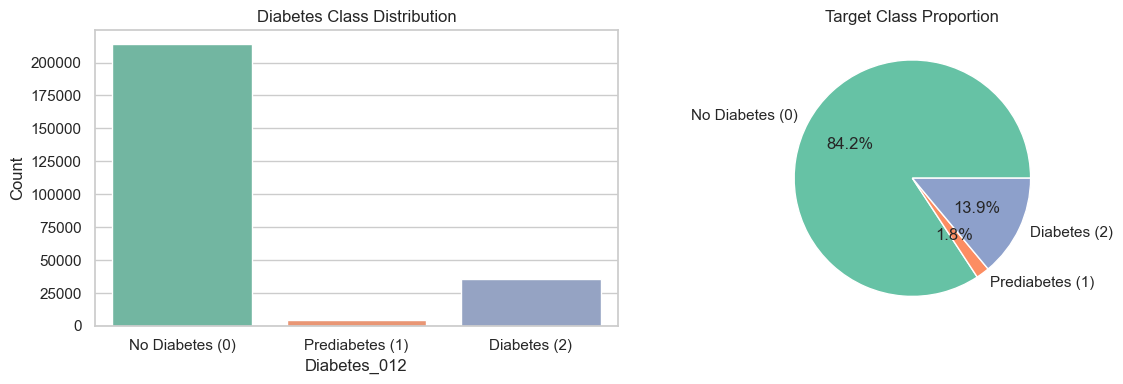


Class counts:
Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['Diabetes_012'].value_counts().sort_index()
labels = ['No Diabetes (0)', 'Prediabetes (1)', 'Diabetes (2)']

sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax[0], palette='Set2')
ax[0].set_title('Diabetes Class Distribution')
ax[0].set_xticklabels(labels)
ax[0].set_ylabel('Count')

target_counts.plot.pie(autopct='%1.1f%%', labels=labels,
                       colors=['#66c2a5','#fc8d62','#8da0cb'], ax=ax[1])
ax[1].set_ylabel('')
ax[1].set_title('Target Class Proportion')

plt.tight_layout()
plt.show()

print(f'\nClass counts:\n{target_counts}')

### 3.2 BMI Distribution by Diabetes Status

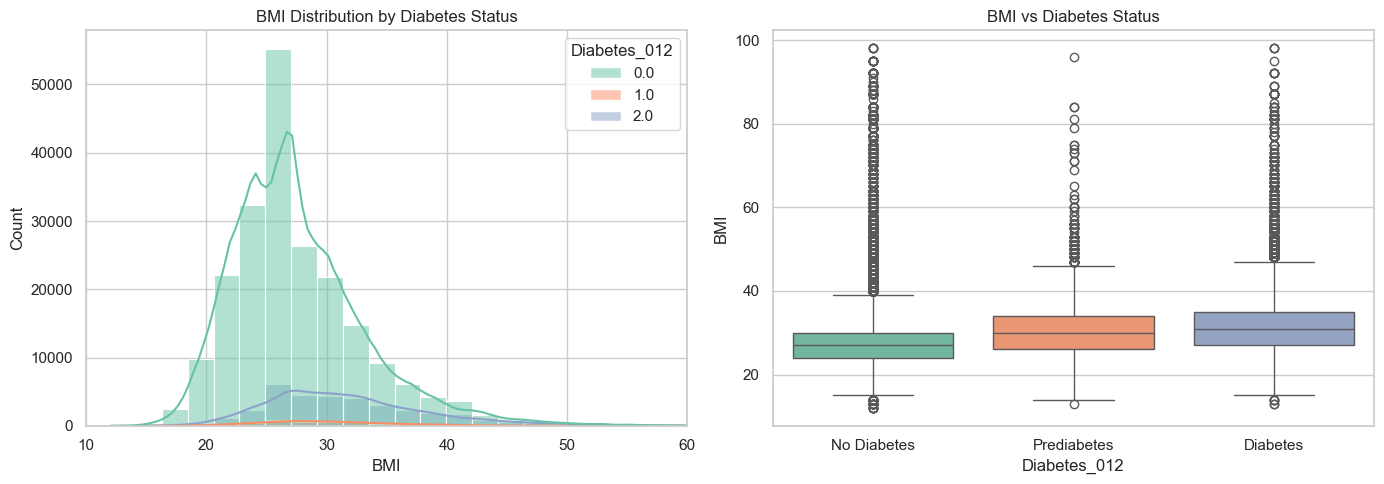

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='BMI', hue='Diabetes_012', kde=True, ax=axes[0], palette='Set2', bins=40)
axes[0].set_title('BMI Distribution by Diabetes Status')
axes[0].set_xlim(10, 60)

sns.boxplot(x='Diabetes_012', y='BMI', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('BMI vs Diabetes Status')
axes[1].set_xticklabels(['No Diabetes', 'Prediabetes', 'Diabetes'])

plt.tight_layout()
plt.show()

### 3.3 Age Category Distribution

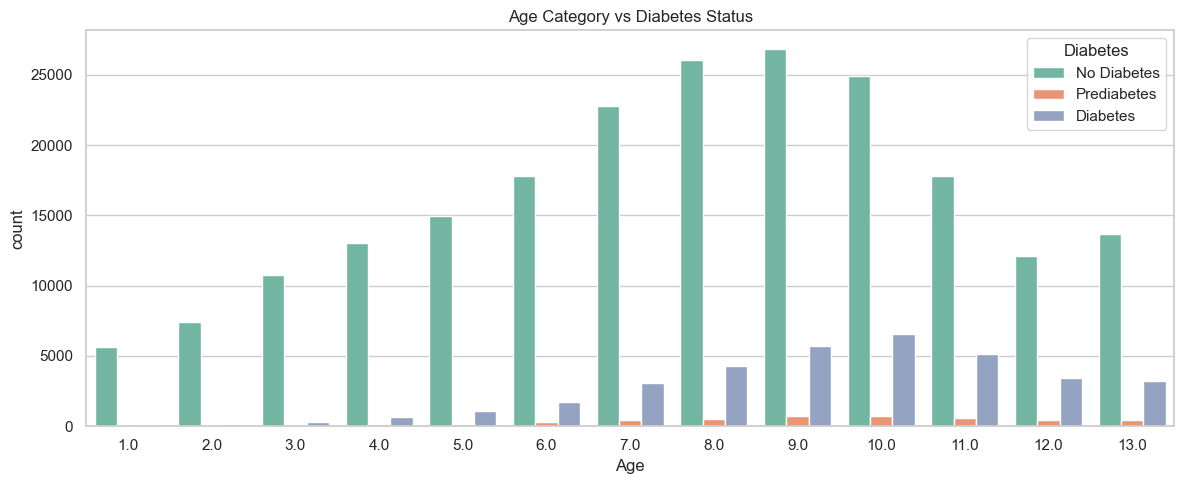

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.countplot(x='Age', hue='Diabetes_012', data=df, palette='Set2', ax=ax)
ax.set_title('Age Category vs Diabetes Status')
ax.legend(title='Diabetes', labels=['No Diabetes', 'Prediabetes', 'Diabetes'])
plt.tight_layout()
plt.show()

### 3.4 Key Binary Features vs Diabetes

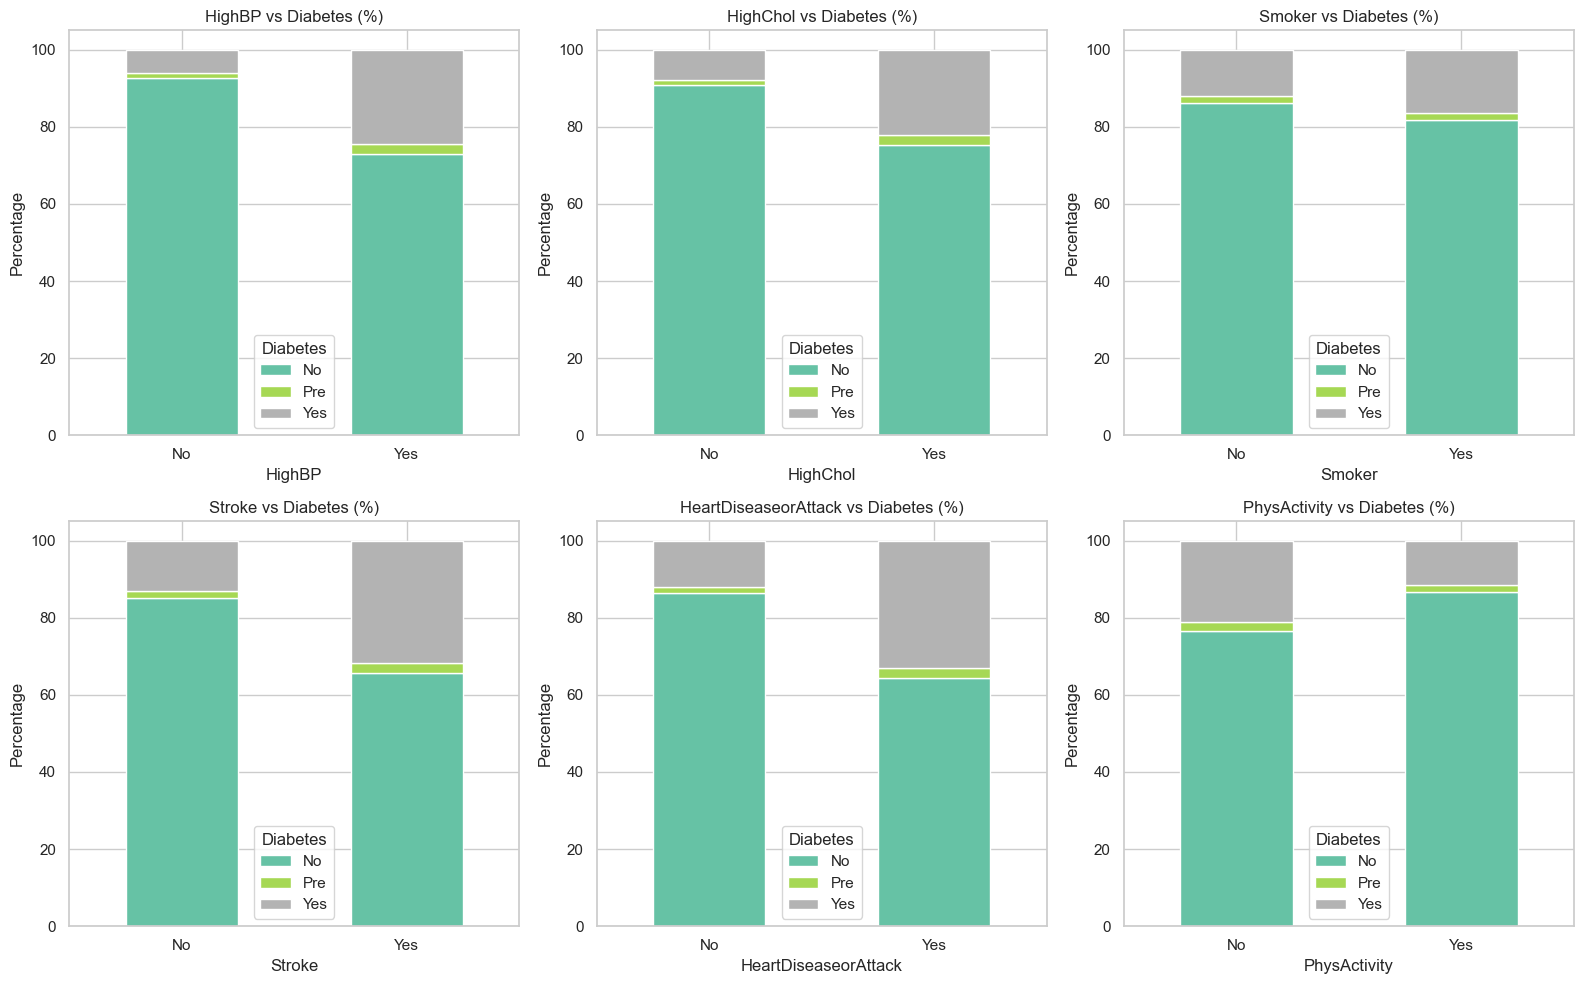

In [9]:
binary_features = ['HighBP', 'HighChol', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(binary_features):
    ax = axes[i // 3, i % 3]
    ct = pd.crosstab(df[col], df['Diabetes_012'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
    ax.set_title(f'{col} vs Diabetes (%)')
    ax.set_ylabel('Percentage')
    ax.legend(title='Diabetes', labels=['No', 'Pre', 'Yes'])
    ax.set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.show()

### 3.5 General Health & Mental Health

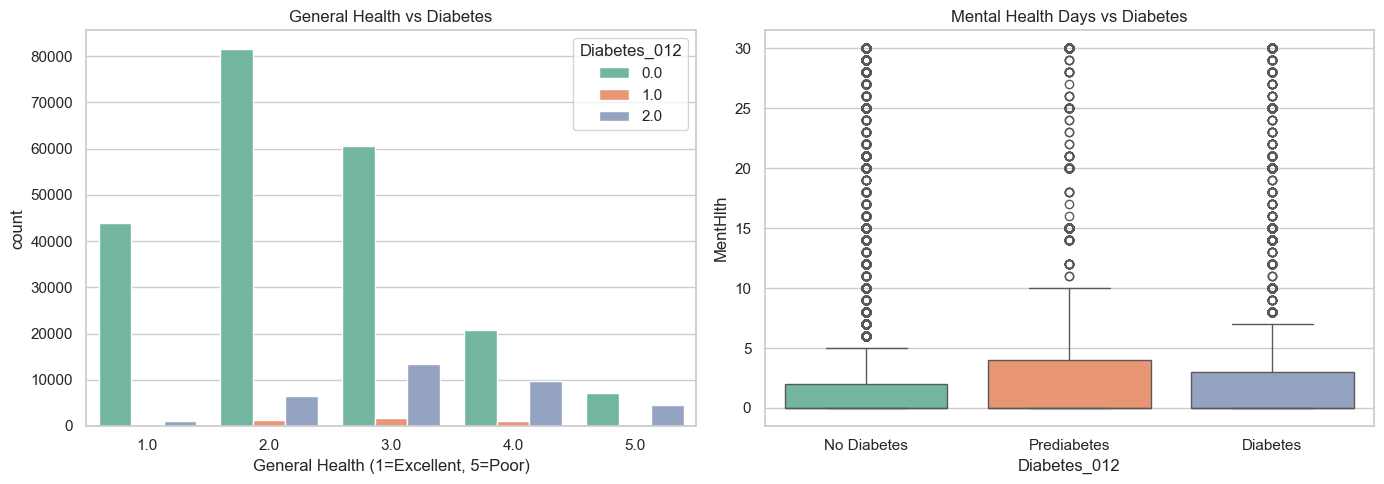

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='GenHlth', hue='Diabetes_012', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('General Health vs Diabetes')
axes[0].set_xlabel('General Health (1=Excellent, 5=Poor)')

sns.boxplot(x='Diabetes_012', y='MentHlth', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Mental Health Days vs Diabetes')
axes[1].set_xticklabels(['No Diabetes', 'Prediabetes', 'Diabetes'])

plt.tight_layout()
plt.show()

### 3.6 Correlation Heatmap

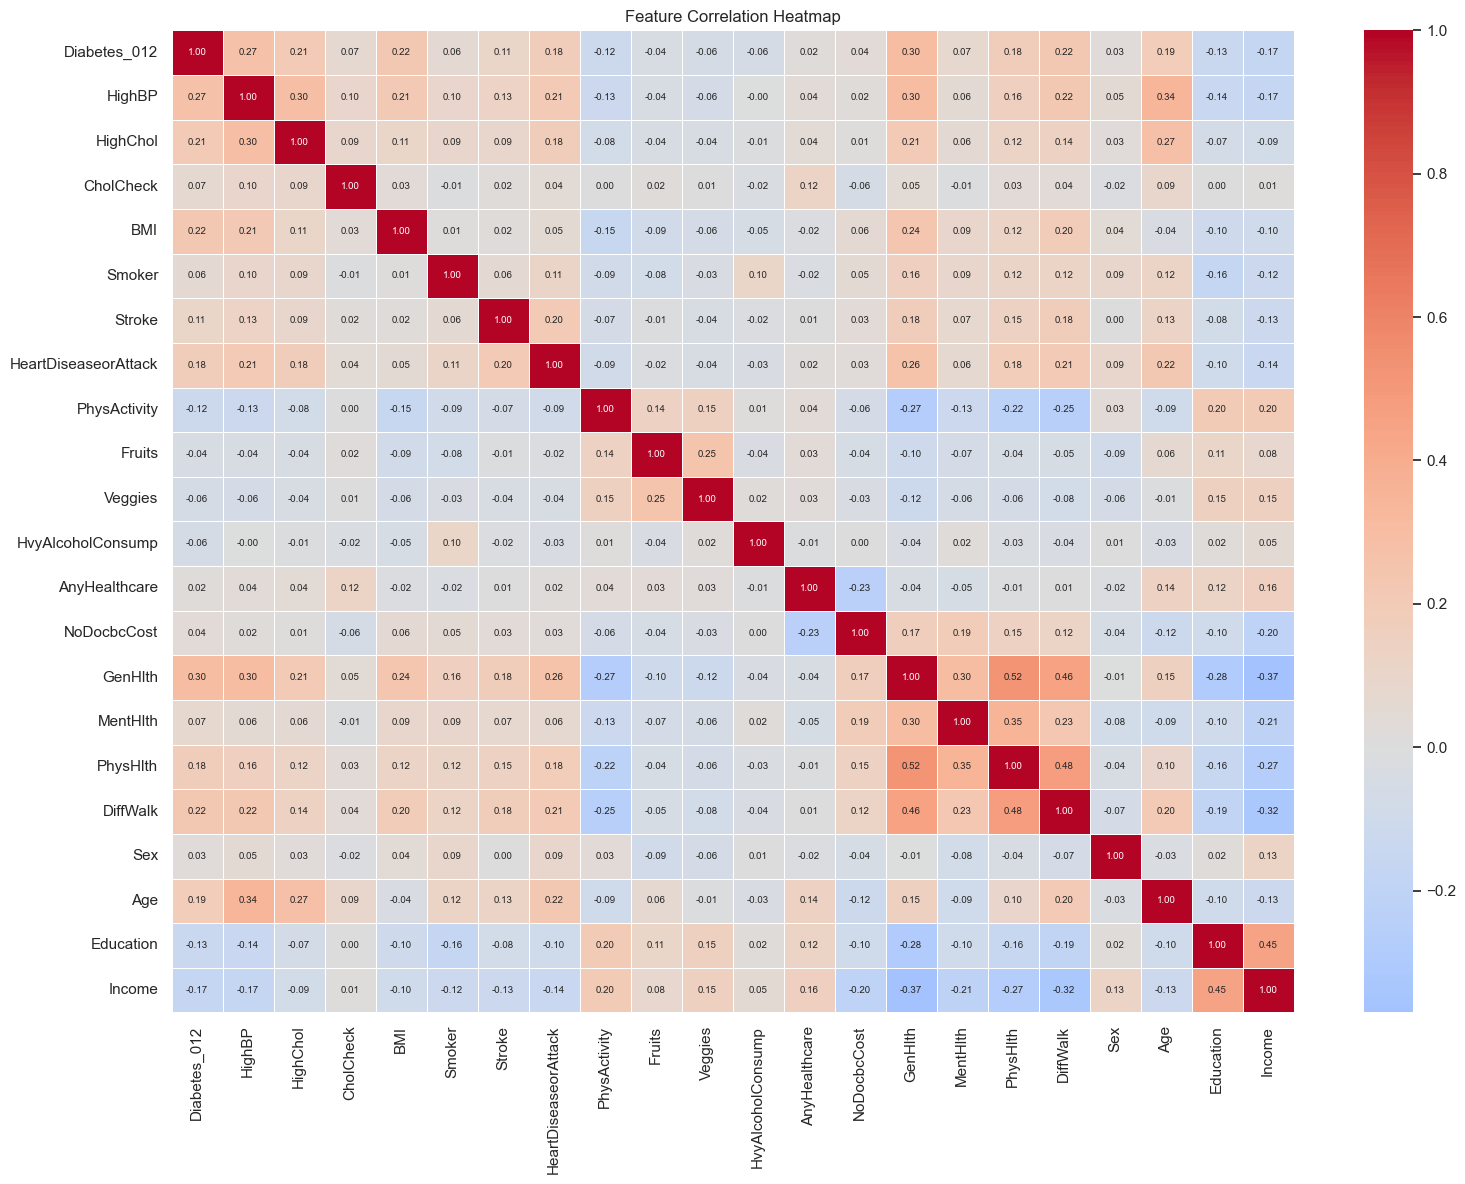

In [11]:
plt.figure(figsize=(16, 12))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

---
## 4. Data Preprocessing

In [12]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012'].astype(int)

print(f'Features shape: {X.shape}')
print(f'Class distribution:\n{y.value_counts().sort_index()}')

Features shape: (253680, 21)
Class distribution:
Diabetes_012
0    213703
1      4631
2     35346
Name: count, dtype: int64


In [13]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE for class imbalance
print('Applying SMOTE...')
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f'After SMOTE — Class distribution:\n{pd.Series(y_train_resampled).value_counts().sort_index()}')

# Save scaler
joblib.dump(scaler, os.path.join(MODELS_DIR, 'diabetes_scaler.pkl'))

print(f'\nTrain set (resampled): {X_train_resampled.shape}')
print(f'Test set: {X_test_scaled.shape}')

Applying SMOTE...
After SMOTE — Class distribution:
Diabetes_012
0    170962
1    170962
2    170962
Name: count, dtype: int64

Train set (resampled): (512886, 21)
Test set: (50736, 21)


---
## 5. Model Training & Comparison

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=7, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=7, random_state=42, eval_metric='mlogloss', verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=7, random_state=42, verbose=-1),
}

results = {}
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'accuracy': acc, 'f1_weighted': f1_w, 'model': model}
    print(f'  Accuracy: {acc:.4f}  |  F1 (weighted): {f1_w:.4f}')

Training Logistic Regression...
  Accuracy: 0.6418  |  F1 (weighted): 0.7184
Training Random Forest...
  Accuracy: 0.7472  |  F1 (weighted): 0.7766
Training Gradient Boosting...
  Accuracy: 0.8422  |  F1 (weighted): 0.8240
Training XGBoost...
  Accuracy: 0.8442  |  F1 (weighted): 0.8221
Training LightGBM...
  Accuracy: 0.8462  |  F1 (weighted): 0.8188


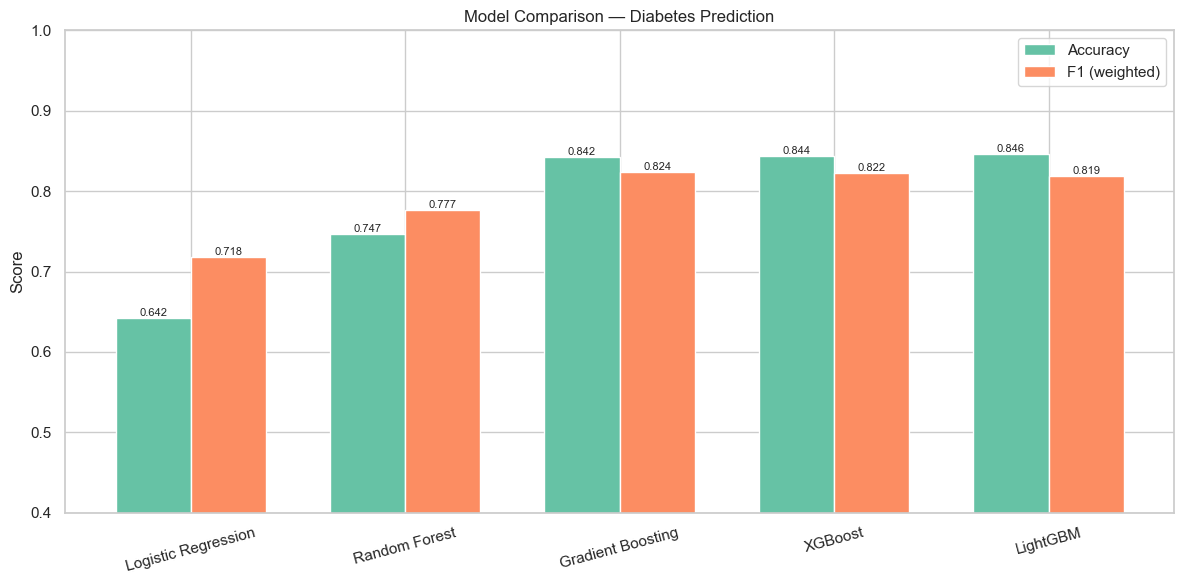

In [15]:
# Comparison bar chart
model_names = list(results.keys())
accuracies = [results[n]['accuracy'] for n in model_names]
f1_scores_w = [results[n]['f1_weighted'] for n in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#66c2a5')
bars2 = ax.bar(x + width/2, f1_scores_w, width, label='F1 (weighted)', color='#fc8d62')

ax.set_ylabel('Score')
ax.set_title('Model Comparison — Diabetes Prediction')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.legend()
ax.set_ylim(0.4, 1.0)
ax.bar_label(bars1, fmt='%.3f', fontsize=8)
ax.bar_label(bars2, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.show()

---
## 6. Best Model — Detailed Evaluation

In [16]:
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_model = results[best_name]['model']
print(f'Best model: {best_name}')

y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

print(f"\nAccuracy:            {accuracy:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")
print(f"F1 Score (macro):    {f1_macro:.4f}")
print(f"ROC-AUC (weighted):  {roc_auc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['No Diabetes', 'Prediabetes', 'Diabetes'])}")

Best model: LightGBM

Accuracy:            0.8462
F1 Score (weighted): 0.8188
F1 Score (macro):    0.4202
ROC-AUC (weighted):  0.8177

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.87      0.96      0.91     42741
 Prediabetes       0.00      0.00      0.00       926
    Diabetes       0.51      0.26      0.35      7069

    accuracy                           0.85     50736
   macro avg       0.46      0.41      0.42     50736
weighted avg       0.81      0.85      0.82     50736



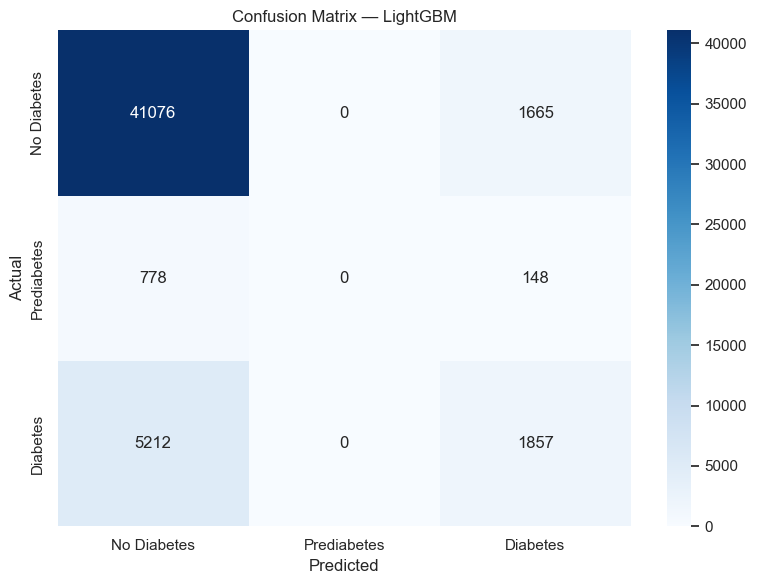

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Prediabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Prediabetes', 'Diabetes'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

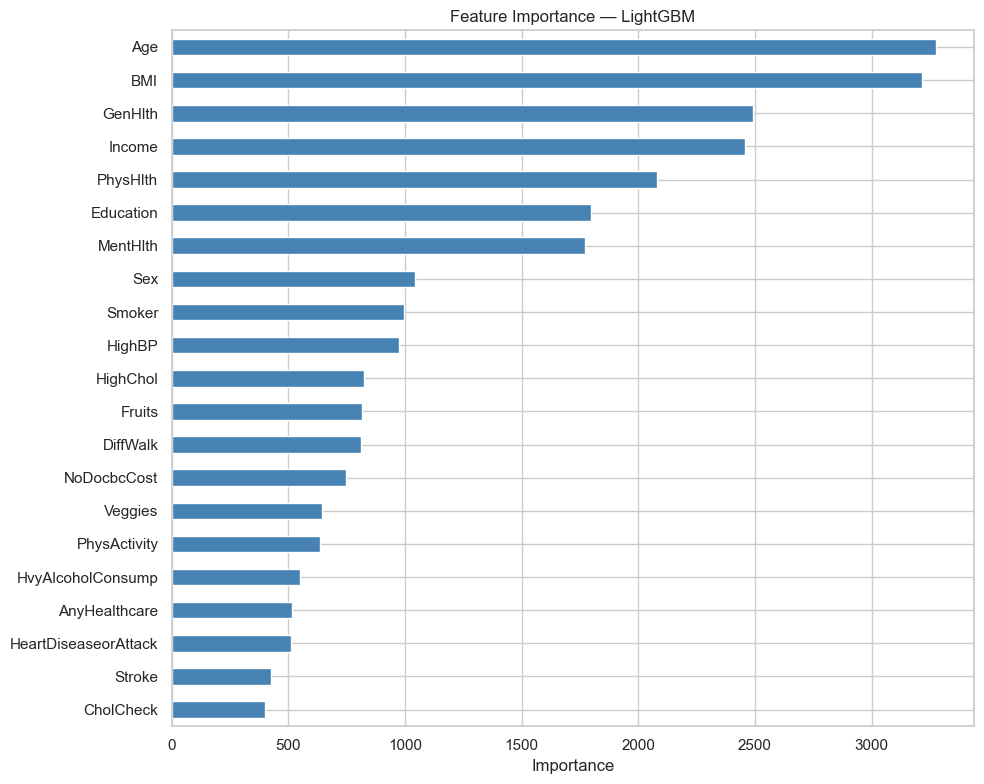

In [18]:
# Feature Importance
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

    plt.figure(figsize=(10, 8))
    feat_imp.plot(kind='barh', color='steelblue')
    plt.title(f'Feature Importance — {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

---
## 7. Save Best Model

In [19]:
joblib.dump(best_model, os.path.join(MODELS_DIR, 'diabetes_model.pkl'))
print(f'Best model ({best_name}) saved to models/diabetes_model.pkl')
print(f'Scaler saved to models/diabetes_scaler.pkl')

Best model (LightGBM) saved to models/diabetes_model.pkl
Scaler saved to models/diabetes_scaler.pkl
